In [1]:
%load_ext autoreload                            
%autoreload 2

# Kinematic morphology via MORDOR

Classify AIDA-TNG **central subhalos** into thin/thick/pseudo-bulge/bulge/halo components. 

MORDOR disc criterion: `(Mthin + Mthick + Mpbulge) / (Mthin + Mthick + Mpbulge + Mbulge + Mhalo) > 0.5`.

In [2]:
import os
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pynbody
from astropy.stats import binom_conf_interval
import gc
from math import e

import temet
from galaxy_sidm.data.aida_tng import (
    get_snap_scale_factor,
    build_central_subhalo_catalog,
    qualifying_central_ids,
)
from galaxy_sidm.morphology import (
    extract_galaxy_hdf5, run_mordor_single, format_mordor_row,
    parse_mordor_output, disc_fraction, component_fractions,
)

plt.rcParams.update({
    'axes.labelsize': 15, 'axes.titlesize': 15, 'figure.titlesize': 17,
    'xtick.labelsize': 12, 'ytick.labelsize': 12, 'legend.fontsize': 12,
})

MODELS = ['CDM', 'SIDM1', 'vSIDM']
model_colors = {'CDM': 'black', 'SIDM1': 'tab:blue', 'vSIDM': 'tab:orange'}
SNAP = 67
h = 0.6774
eps_dm_phys = 0.57

SCRATCH = Path(os.environ.get('SCRATCH',
    '/leonardo_scratch/large/userexternal/acosta01'))
OUT_ROOT = SCRATCH / 'master_thesis_project' / 'data' / 'mordor_galaxies'

NB_DIR = Path('/leonardo/home/userexternal/acosta01/master_thesis_project/notebooks/AIDA-TNG')
FIG_DIR = NB_DIR / 'figures'; FIG_DIR.mkdir(exist_ok=True)


In [3]:
sims = {m: temet.sim(run='aida', variant=m, res=1080, snap=SNAP) for m in MODELS}
catalogs = {m: build_central_subhalo_catalog(sims[m]) for m in MODELS}
qualifying = {m: qualifying_central_ids(catalogs[m], n_star_min=1e4) for m in MODELS}

for m in MODELS:
    print(f"{m}: {len(qualifying[m])} central subhalos with N_star >= 1e4")

CDM: 574 central subhalos with N_star >= 1e4
SIDM1: 625 central subhalos with N_star >= 1e4
vSIDM: 582 central subhalos with N_star >= 1e4


Top 10 most massive galaxies (M_star) among the qualifying ones:
1. Subhalo ID: 0, M_star: 1.17e+12 Msun, N_star: 2411062
2. Subhalo ID: 13282, M_star: 8.08e+11 Msun, N_star: 1688670
3. Subhalo ID: 9236, M_star: 6.46e+11 Msun, N_star: 1342220
4. Subhalo ID: 18136, M_star: 6.28e+11 Msun, N_star: 1289511
5. Subhalo ID: 21428, M_star: 5.44e+11 Msun, N_star: 1137812
6. Subhalo ID: 15985, M_star: 4.11e+11 Msun, N_star: 827613
7. Subhalo ID: 29145, M_star: 4.01e+11 Msun, N_star: 830074
8. Subhalo ID: 19841, M_star: 3.94e+11 Msun, N_star: 827265
9. Subhalo ID: 35604, M_star: 3.90e+11 Msun, N_star: 819356
10. Subhalo ID: 30315, M_star: 3.43e+11 Msun, N_star: 710939
HDF5: /leonardo_scratch/large/userexternal/acosta01/master_thesis_project/data/mordor_galaxies/CDM/Gal_000000.hdf5  (2335.8 MB)
  N_gas  = 17523815
  N_dm   = 22893437
  N_star = 2411062  (expected 2411062)


/leonardo/home/userexternal/acosta01/.local/lib/python3.11/site-packages/pynbody/snapshot/gadgethdf.py:1016: UserWarning: Unable to find cosmological factors in HDF file; assuming position is 3.09e+21 a h**-1
  warnings.warn("Unable to find cosmological factors in HDF file; assuming position is %s" % dist_unit)
/leonardo/home/userexternal/acosta01/.local/lib/python3.11/site-packages/pynbody/snapshot/gadgethdf.py:1021: UserWarning: Unable to find cosmological factors in HDF file; assuming velocity is 1.00e+05 a**1/2
  warnings.warn("Unable to find cosmological factors in HDF file; assuming velocity is %s" % vel_unit)
/leonardo/home/userexternal/acosta01/.local/lib/python3.11/site-packages/pynbody/snapshot/gadgethdf.py:1027: UserWarning: Unable to find cosmological factors in HDF file; assuming mass is 1.99e+43 h**-1
  warnings.warn("Unable to find cosmological factors in HDF file; assuming mass is %s" % mass_unit)
/leonardo/home/userexternal/acosta01/.local/lib/python3.11/site-packages/

Ecut =  -0.88384056

Component masses [Msun]:
  Excluded particles  M=1.784e+10  N=39635
  Thin disc     M=1.234e+11  N=255170
  Thick disc    M=1.249e+11  N=257737
  Pseudo-bulge  M=1.502e+10  N=33042
  Bulge         M=6.975e+10  N=153098
  Halo          M=8.156e+11  N=1672380

IsDisc (Zana) = False  (frac=0.229)
Ecut = -0.891


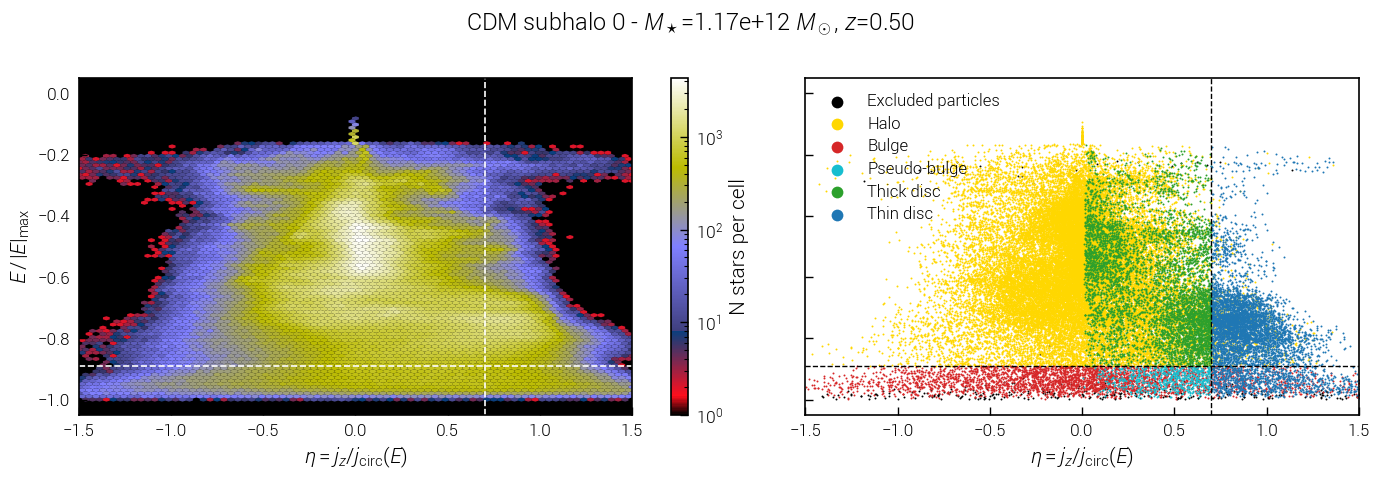

In [4]:
for _name in ('gal', 'snap_'):
    if _name in dir():
        del globals()[_name]
gc.collect()

test_model = 'CDM'
cat = catalogs[test_model]
ids = qualifying[test_model]

#print the 10 most massive galaxies in the catalog among the qualifying ones
print("Top 10 most massive galaxies (M_star) among the qualifying ones:")
top10_ids = ids[np.argsort(cat['Mstar'][ids])][-10:][::-1]
for i, subid in enumerate(top10_ids):
    print(f"{i+1}. Subhalo ID: {subid}, M_star: {cat['Mstar'][subid]:.2e} Msun, N_star: {cat['N_star'][subid]}")

test_subid = int(ids[np.argmax(cat['Mstar'][ids])])
test_path = OUT_ROOT / test_model / f'Gal_{test_subid:06d}.hdf5'

extract_galaxy_hdf5(
    base_path=cat['basePath'], snap=cat['snap'], subhalo_id=test_subid,
    out_path=test_path, h=h, soft_phys_kpc=eps_dm_phys,
)
print(f'HDF5: {test_path}  ({test_path.stat().st_size / 1e6:.1f} MB)')

snap_ = pynbody.load(str(test_path))
print(f"  N_gas  = {len(snap_.g)}")
print(f"  N_dm   = {len(snap_.d)}")
print(f"  N_star = {len(snap_.s)}  (expected {cat['N_star'][test_subid]})")
del snap_; gc.collect()

gal = run_mordor_single(test_path, mode='cosmo_sim', soft_phys_kpc=eps_dm_phys)

morph = np.asarray(gal.s['morph'])
eta   = np.asarray(gal.s['jz_by_jzcirc'])
te    = np.asarray(gal.s['te'])
mass  = np.asarray(gal.s['mass'])
classified = morph != 0
Emax  = float(np.abs(te[classified]).max()) if classified.any() else 1.0
te_n  = te / Emax
low_E = (morph == 3) | (morph == 4)
Ecut  = float(np.max(te_n[low_E])) if low_E.any() else 0.0

# MORDOR-style summary from the per-particle arrays
comp_names = {0: 'Excluded particles', 1: 'Thin disc', 2: 'Thick disc',
              3: 'Pseudo-bulge', 4: 'Bulge', 5: 'Halo'}
print('\nComponent masses [Msun]:')
for k, label in comp_names.items():
    m_k = float(mass[morph == k].sum())
    print(f'  {label:12s}  M={m_k:.3e}  N={(morph==k).sum()}')
mthin   = float(mass[morph == 1].sum())
mthick  = float(mass[morph == 2].sum())
mpbulge = float(mass[morph == 3].sum())
mbulge  = float(mass[morph == 4].sum())
mhalo   = float(mass[morph == 5].sum())
mbound  = mthin + mthick + mpbulge + mbulge + mhalo
disc_frac = (mthin + mthick + mpbulge) / mbound if mbound > 0 else 0.0
print(f'\nIsDisc (Zana) = {disc_frac > 0.5}  (frac={disc_frac:.3f})')
print(f'Ecut = {Ecut:.3f}')

# (eta, E) plot — Zana+22 Fig. 2 style
comp_colors = {0: 'black', 1: 'tab:blue', 2: 'tab:green',
               3: 'tab:cyan', 4: 'tab:red', 5: 'gold'}

if len(eta) > 50000:
    rng = np.random.default_rng(0)
    sub = rng.choice(len(eta), 50000, replace=False)
else:
    sub = np.arange(len(eta))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True,
                          constrained_layout=True)

ax = axes[0]
ax.set_facecolor('black')
hb = ax.hexbin(eta[classified], te_n[classified], gridsize=80, mincnt=1,
               cmap='gist_stern', norm=LogNorm())
ax.axvline(0.7,  color='white', ls='--', lw=1.2)
ax.axhline(Ecut, color='white', ls='--', lw=1.2)
ax.set_xlabel(r'$\eta = j_z / j_{\rm circ}(E)$')
ax.set_ylabel(r'$E\,/\,|E|_{\rm max}$')
# ax.set_title('Phase-space density (η, E)')
fig.colorbar(hb, ax=ax, label='N stars per cell')

ax = axes[1]
for k in [0, 5, 4, 3, 2, 1]:
    sel = (morph[sub] == k)
    if not sel.any():
        continue
    ax.scatter(eta[sub][sel], te_n[sub][sel], s=2,# alpha=0.5,
               color=comp_colors[k],
               label=f'{comp_names[k]}') # (N={int((morph==k).sum())})
ax.axvline(0.7,  color='black', ls='--', lw=1.0)
ax.axhline(Ecut, color='black', ls='--', lw=1.0)
ax.set_xlabel(r'$\eta = j_z / j_{\rm circ}(E)$')
# ax.set_title(f'Components — $E_{{\\rm cut}}$ = {Ecut:.2f}')
ax.legend(loc='upper left', markerscale=6, framealpha=0.85)

ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.05, 0.05)
fig.suptitle(f'CDM subhalo {test_subid} - '
             rf'$M_\star$={cat["Mstar"][test_subid]:.2e} $M_\odot$, '
             f'$z$={cat["redshift"]:.2f}')
plt.savefig(FIG_DIR / f'mordor_eta_E_subhalo_{test_subid}.pdf',
             dpi=150, bbox_inches='tight')
plt.show()

## Run extraction + decomposition (outside the notebook)

Production extraction and decomposition live in `scripts/`. Run from a shell, one command per model:

```bash
python scripts/run_mordor.py --model CDM   --snap 67 --max-workers 64 --mem-per-worker 2G
python scripts/run_mordor.py --model SIDM1 --snap 67 --max-workers 64 --mem-per-worker 2G
python scripts/run_mordor.py --model vSIDM --snap 67 --max-workers 64 --mem-per-worker 2G
```

`run_mordor.py` auto-invokes `scripts/extract_galaxies.py` first if any per-galaxy HDF5 is missing. Outputs land at `$SCRATCH/master_thesis_project/data/mordor_galaxies/outputs/morphology_<MODEL>.txt`. Re-run with `--resume` to pick up after an interruption.

In [5]:
OUTPUTS_DIR = OUT_ROOT / 'outputs'
mordor_outputs = {m: OUTPUTS_DIR / f'snap_{SNAP:03d}/morphology_{m}.txt' for m in MODELS}

mordor_dfs = {}
for model in MODELS:
    df = parse_mordor_output(mordor_outputs[model], catalog=catalogs[model])
    df['model'] = model
    mordor_dfs[model] = df
    n_disc = int((df['IsDisc'] == 1).sum())
    print(f'{model}: {len(df)} classified, {n_disc} discs ({100*n_disc/max(len(df),1):.1f}%)')

mordor_all = pd.concat([df.reset_index() for df in mordor_dfs.values()])
mordor_all = mordor_all.set_index(['model', 'subhalo_id'])

with open(OUT_ROOT / 'mordor_results.pkl', 'wb') as f:
    pickle.dump(mordor_all, f)
print(f'Saved combined results to {OUT_ROOT / "mordor_results.pkl"}')

CDM: 571 classified, 460 discs (80.6%)
SIDM1: 624 classified, 503 discs (80.6%)
vSIDM: 579 classified, 461 discs (79.6%)
Saved combined results to /leonardo_scratch/large/userexternal/acosta01/master_thesis_project/data/mordor_galaxies/mordor_results.pkl


Mthin/Mstar percentiles (16, 50, 84):
  CDM: median=0.467  [16, 84]=[0.229, 0.605]  (N=571)
  SIDM1: median=0.433  [16, 84]=[0.205, 0.579]  (N=624)
  vSIDM: median=0.432  [16, 84]=[0.222, 0.576]  (N=579)


/tmp/ipykernel_936167/1772412676.py:49: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


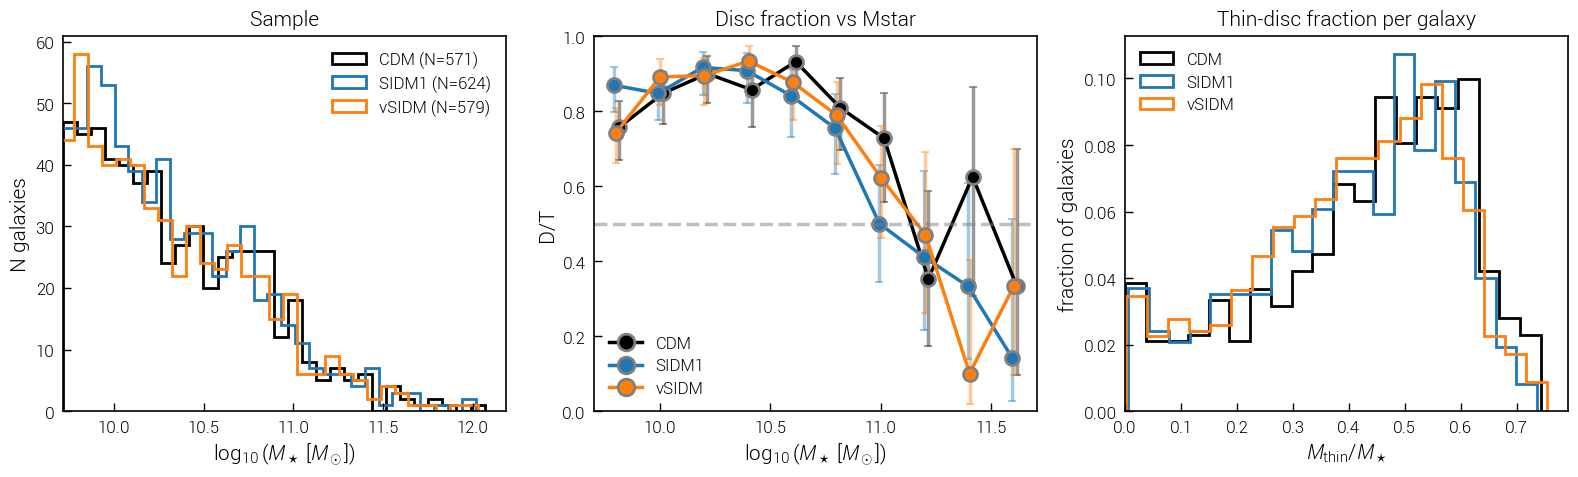

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
for model in MODELS:
    df = mordor_dfs[model]
    ax.hist(np.log10(df['Mstar']), bins=30, histtype='step', lw=2,
            color=model_colors[model], label=f"{model} (N={len(df)})")
ax.set_xlabel(r'$\log_{10}(M_\star\;[M_\odot])$'); ax.set_ylabel('N galaxies')
ax.legend(); ax.set_title('Sample'); ax.set_xlim(np.min(np.log10(mordor_dfs['CDM']['Mstar'])))

ax = axes[1]
for model in MODELS:
    df = mordor_dfs[model]
    log_m = np.log10(df['Mstar'].values)
    bins = np.arange(log_m.min(), log_m.max() + 0.2, 0.2)
    centres, fracs, lo, hi = [], [], [], []
    for i in range(len(bins)-1):
        m = (log_m >= bins[i]) & (log_m < bins[i+1])
        n_total = int(m.sum())                 
        if n_total >= 5:                       
            n_disc = int((df['IsDisc'].values[m] == 1).sum())
            f = n_disc / n_total               
            l, h = binom_conf_interval(n_disc, n_total, confidence_level=0.95, interval='wilson')
            centres.append(0.5*(bins[i]+bins[i+1]))
            #fracs.append(float((df['IsDisc'].values[m] == 1).mean()))
            fracs.append(f)
            lo.append(f - l)
            hi.append(h - f)
    yerr = np.array([lo, hi])
    ax.plot(centres, fracs, '-o', color=model_colors[model], label=model, ms=10, markeredgecolor='grey', markeredgewidth=2)
    ax.errorbar(centres, fracs, yerr=yerr, fmt='none', color=model_colors[model], alpha=0.4, capsize=3, capthick=1.5, zorder=0)
ax.axhline(0.5, color='gray', ls='--', alpha=0.5)
ax.set_xlabel(r'$\log_{10}(M_\star\;[M_\odot])$'); ax.set_ylabel('disc fraction')
ax.set_ylim(0, 1); ax.legend(); ax.set_title('Disc fraction vs Mstar')

ax = axes[2]
print('Mthin/Mstar percentiles (16, 50, 84):')
for model in MODELS:
    df = mordor_dfs[model]
    x = (df['Mthin'] / df['Mstar']).values
    weights = np.ones_like(x) / len(x)
    ax.hist(x, bins=20, weights=weights, histtype='step', lw=2,
            color=model_colors[model], label=model)
    p16, p50, p84 = np.percentile(x, [16, 50, 84])
    print(f'  {model}: median={p50:.3f}  [16, 84]=[{p16:.3f}, {p84:.3f}]  (N={len(x)})')
ax.set_xlabel(r'$M_{\rm thin} / M_\star$'); ax.set_ylabel('fraction of galaxies')
ax.legend(); ax.set_title('Thin-disc fraction per galaxy'); ax.set_xlim(0)

plt.tight_layout()
plt.savefig(FIG_DIR / 'mordor_overview.pdf', dpi=150, bbox_inches='tight')
plt.show()

## Interacting galaxies

In [7]:
# Compute satellite mass ratio for each CDM central in the MORDOR sample
# A satellite counts as "interacting" only if BOTH:
#   - M*_sat / M*_central >= 0.2  (massive enough to perturb)
#   - r_sep = d(host, sat) / (R_half*,host + R_half*,sat) < 2  (spatially overlapping)
M_RATIO_MIN = 0.2
R_SEP_MAX = 10.
sim_cdm = sims['CDM']
sub_mstar = sim_cdm.units.codeMassToMsun(sim_cdm.subhalos('SubhaloMassType')[:, 4])
sub_grnr = sim_cdm.subhalos('SubhaloGrNr')
sub_pos = sim_cdm.units.codeLengthToComovingKpc(sim_cdm.subhalos('SubhaloPos'))
sub_hmrs = sim_cdm.units.codeLengthToComovingKpc(sim_cdm.subhalos('SubhaloHalfmassRadType')[:, 4])
box = sim_cdm.units.codeLengthToComovingKpc(sim_cdm.boxSize)

df = mordor_dfs['CDM']
sat_ratio = np.zeros(len(df))
sat_rsep = np.full(len(df), np.inf)
for i, sid in enumerate(df.index):
    if sub_mstar[sid] <= 0 or sub_hmrs[sid] <= 0:
        continue
    grnr = sub_grnr[sid]
    same_fof = np.where(sub_grnr == grnr)[0]
    other = same_fof[same_fof != sid]
    if len(other) == 0:
        continue
    # else:
    #     sat_ratio[i] = float(sub_mstar[other].max() / sub_mstar[sid])
    mratio = sub_mstar[other] / sub_mstar[sid]
    dx = sub_pos[other] - sub_pos[sid]
    dx -= box * np.round(dx / box) # periodic wrapping
    d = np.linalg.norm(dx, axis=1)
    denom = sub_hmrs[sid] + sub_hmrs[other]
    rsep = np.where(denom > 0, d / np.maximum(denom, 1e-30), np.inf)
    close_massive = (mratio >= M_RATIO_MIN) & (rsep < R_SEP_MAX)
    if close_massive.any():
        # most massive satellite satisfying both cuts
        k = np.argmax(np.where(close_massive, mratio, -1.0))
        sat_ratio[i] = float(mratio[k])
        sat_rsep[i]  = float(rsep[k])
df['sat_mass_ratio'] = sat_ratio
df['sat_r_sep']      = sat_rsep

interacting = df['sat_mass_ratio'] >= M_RATIO_MIN
print(f'Interacting (M*_sat/M*_cen >= {M_RATIO_MIN} AND r_sep < {R_SEP_MAX}):'
      f'{interacting.sum()}/{len(df)} ({100*interacting.sum()/len(df):.1f}%)')

log_m = np.log10(df['Mstar'].values)
bins = np.arange(9.0, 13.0, 0.5)
print(f'\nFraction interacting by log M_star bin:')
for i in range(len(bins) - 1):
    in_bin = (log_m >= bins[i]) & (log_m < bins[i + 1])
    if in_bin.sum() > 0:
        n_int = int((in_bin & interacting).sum())
        print(f'  [{bins[i]:.1f}, {bins[i+1]:.1f}]:  '
              f'{n_int}/{in_bin.sum()} ({100*n_int/in_bin.sum():.1f}%)')

mthin_frac = df['Mthin'] / df['Mstar']
print(f'\nMedian M_thin / M_*:')
print(f'  interacting:     {mthin_frac[interacting].median():.3f}  (N={interacting.sum()})')
print(f'  non-interacting: {mthin_frac[~interacting].median():.3f}  (N={(~interacting).sum()})')

print(f'\nIsDisc rate (Zana):')
print(f'  interacting:     {df["IsDisc"][interacting].mean():.3f}')
print(f'  non-interacting: {df["IsDisc"][~interacting].mean():.3f}')

print(f'\nFraction of total stellar mass in interacting:'
      f' {df["Mstar"][interacting].sum() / df["Mstar"].sum():.3f}')


Interacting (M*_sat/M*_cen >= 0.2 AND r_sep < 10.0):15/571 (2.6%)

Fraction interacting by log M_star bin:
  [9.5, 10.0]:  3/164 (1.8%)
  [10.0, 10.5]:  4/212 (1.9%)
  [10.5, 11.0]:  3/141 (2.1%)
  [11.0, 11.5]:  4/43 (9.3%)
  [11.5, 12.0]:  1/10 (10.0%)
  [12.0, 12.5]:  0/1 (0.0%)

Median M_thin / M_*:
  interacting:     0.383  (N=15)
  non-interacting: 0.468  (N=556)

IsDisc rate (Zana):
  interacting:     0.800
  non-interacting: 0.806

Fraction of total stellar mass in interacting: 0.049


/tmp/ipykernel_936167/155766832.py:41: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


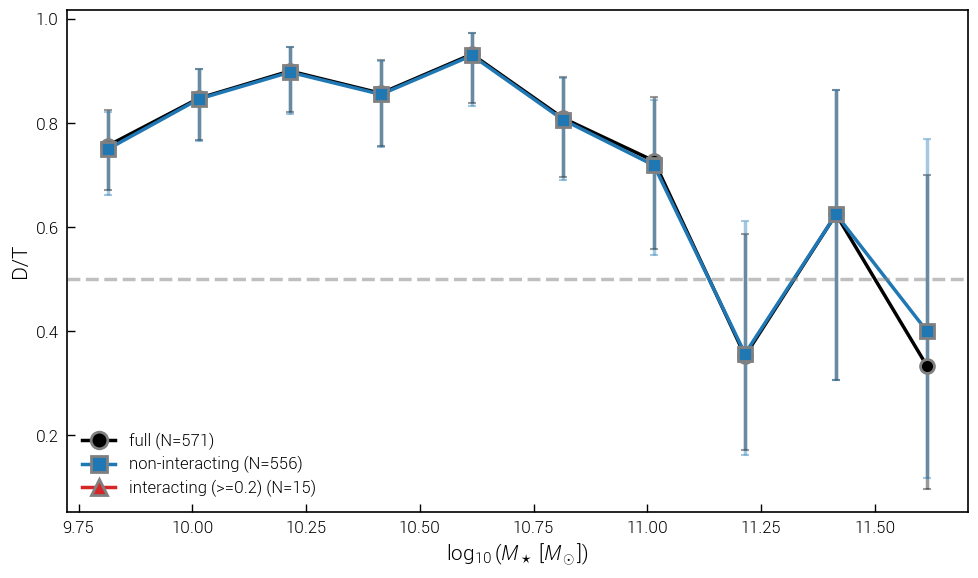

In [ ]:
# Bias diagnostic: CDM disc fraction vs M_star, full vs non-interacting vs interacting
df = mordor_dfs['CDM']
interacting = df['sat_mass_ratio'] >= 0.2

subsets = {
    'full':                   (df,                'black',     'o'),
    'non-interacting':        (df[~interacting],  'tab:blue',  's'),
    'interacting (>=0.2)':    (df[interacting],   'tab:red',   '^'),
}

fig, ax = plt.subplots(figsize=(10, 6))
for label, (sub_df, color, marker) in subsets.items():
    log_m = np.log10(sub_df['Mstar'].values)
    bins = np.arange(log_m.min(), log_m.max() + 0.2, 0.2)
    centres, fracs, lo, hi = [], [], [], []
    for i in range(len(bins) - 1):
        m = (log_m >= bins[i]) & (log_m < bins[i + 1])
        n_total = int(m.sum())
        if n_total >= 5:
            n_disc = int((sub_df['IsDisc'].values[m] == 1).sum())
            f = n_disc / n_total
            l, h = binom_conf_interval(n_disc, n_total,
                                        confidence_level=0.95, interval='wilson')
            centres.append(0.5 * (bins[i] + bins[i + 1]))
            fracs.append(f)
            lo.append(f - l)
            hi.append(h - f)
    yerr = np.array([lo, hi])
    ax.plot(centres, fracs, '-' + marker, color=color,
            label=f'{label} (N={len(sub_df)})',
            ms=10, markeredgecolor='grey', markeredgewidth=2)
    ax.errorbar(centres, fracs, yerr=yerr, fmt='none', color=color,
                alpha=0.4, capsize=3, capthick=1.5, zorder=0)

ax.axhline(0.5, color='gray', ls='--', alpha=0.5)
ax.set_xlabel(r'$\log_{10}(M_\star\;[M_\odot])$')
ax.set_ylabel('disc fraction')
# ax.set_ylim(0, 1)
ax.legend()
# ax.set_title('CDM disc fraction vs Mstar - interacting bias diagnostic')
plt.tight_layout()
plt.savefig(FIG_DIR / 'cdm_disc_fraction_interacting_bias.pdf', dpi=150, bbox_inches='tight')
plt.show()


CDM interacting galaxies (sat M*/M* >= 0.2): 15 / 571 (2.6%)

Selected 6 galaxies (log M_star -> subhalo_id, sat_ratio):
  log M*=9.78  subhalo 75537  sat_ratio=0.56
  log M*=9.89  subhalo 85326  sat_ratio=0.44
  log M*=10.24  subhalo 67504  sat_ratio=0.65
  log M*=10.59  subhalo 64312  sat_ratio=0.35
  log M*=11.17  subhalo 43846  sat_ratio=0.27
  log M*=11.61  subhalo 15985  sat_ratio=0.21

=== subhalo 75537: log M*=9.78, sat_ratio=0.56 ===
Loaded [/leonardo/home/userexternal/acosta01/temet.cache/e7f3dd93/cache/f_momentOfInertiaTensor_5e5a51790cb8e2e9.hdf5].
Loaded [/leonardo/home/userexternal/acosta01/temet.cache/e7f3dd93/cache/f_momentOfInertiaTensor_5e5a51790cb8e2e9.hdf5].
Loaded [/leonardo/home/userexternal/acosta01/temet.cache/e7f3dd93/cache/f_momentOfInertiaTensor_5e5a51790cb8e2e9.hdf5].
Loaded: [grids//sphMap.67.gas.coldens_msunkpc2.93a31ef8efec83c8.hdf5]
Loaded: [grids//sphMap.67.stars.coldens_msunkpc2.37f2ef3b42ff4afe.hdf5]
Loaded: [grids//sphMap.67.stars.vrad.700b33e8c59ec1

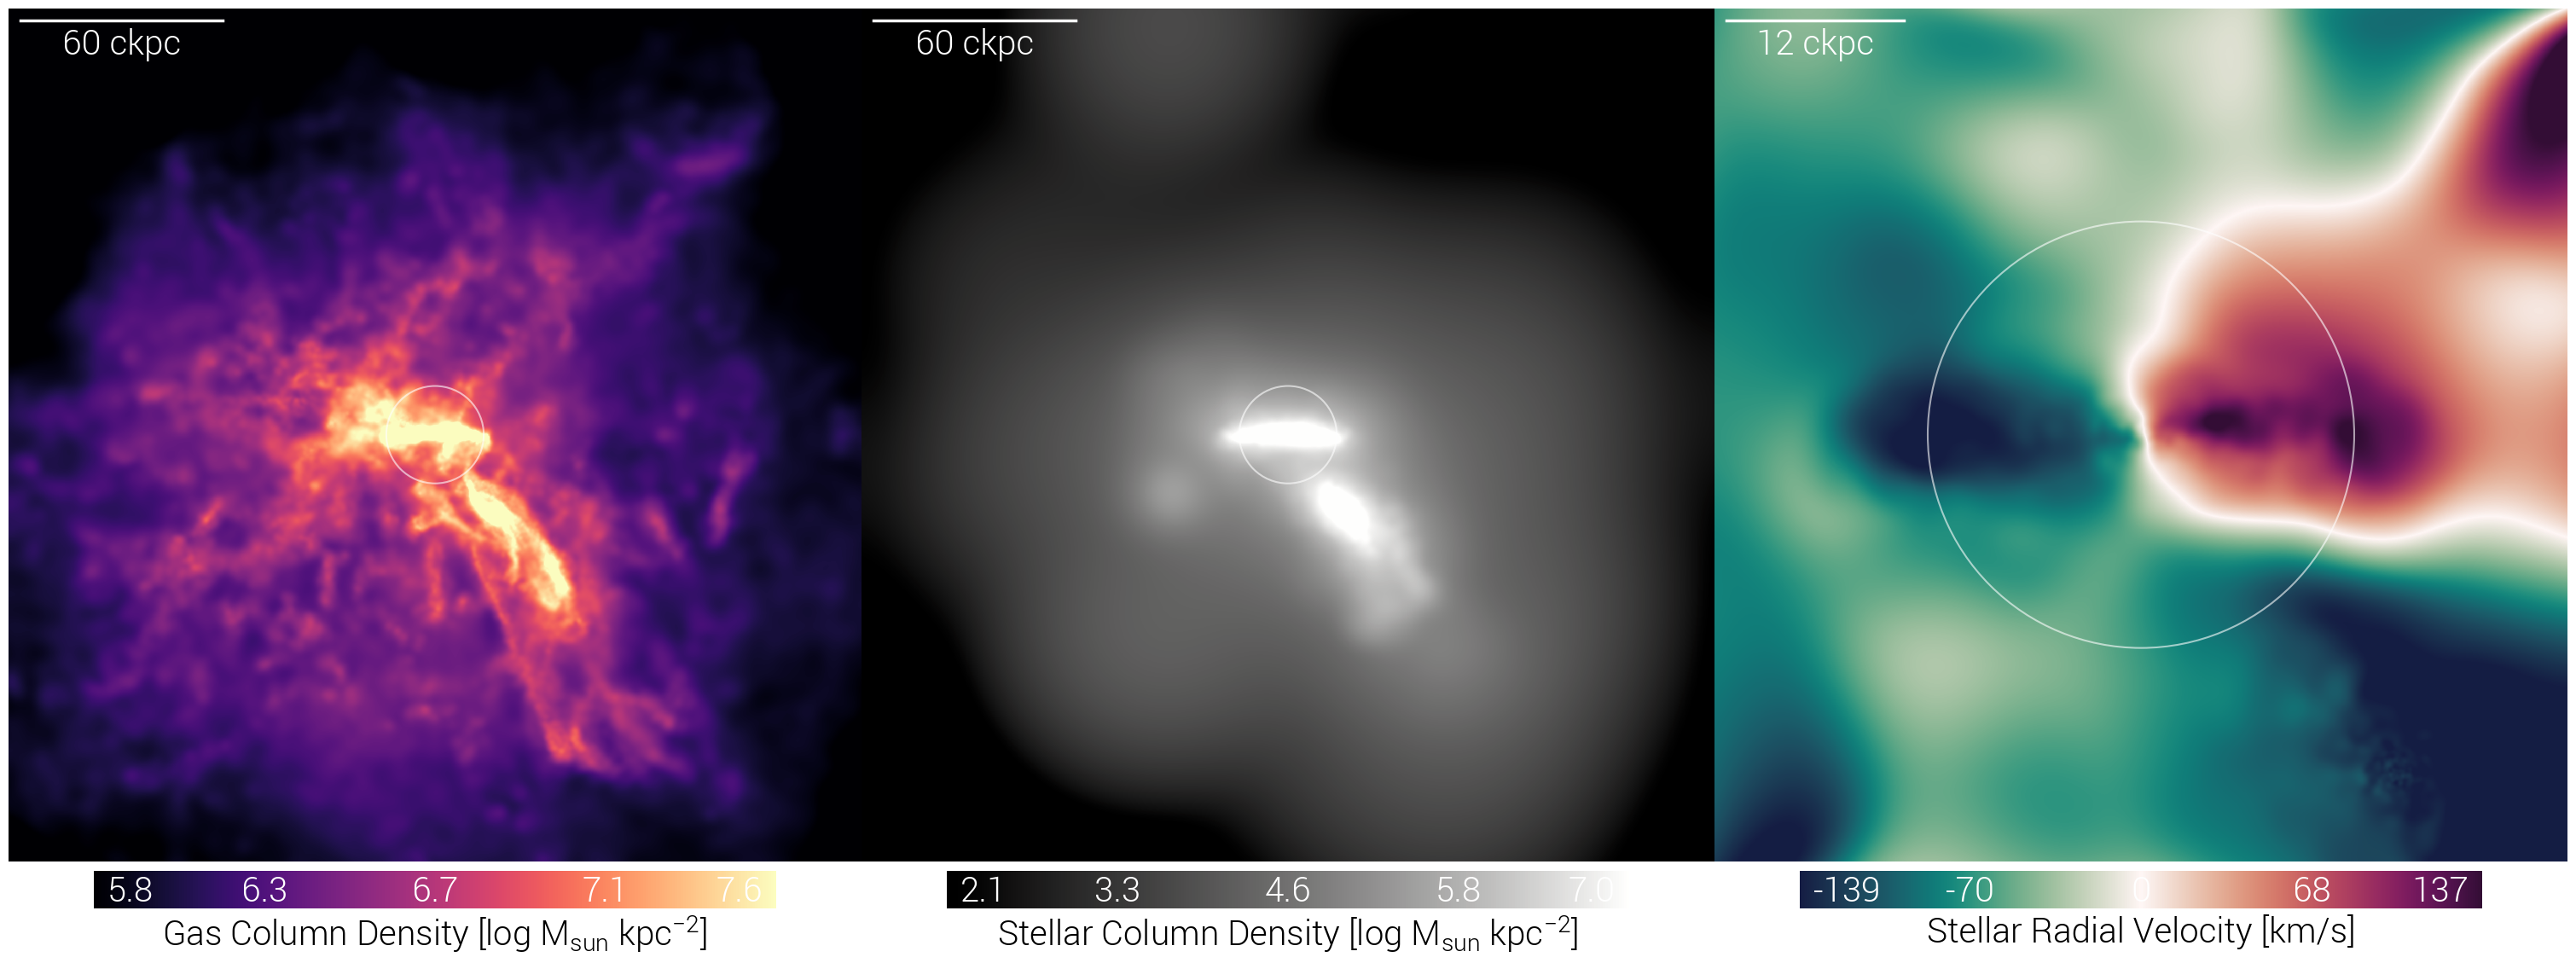


=== subhalo 85326: log M*=9.89, sat_ratio=0.44 ===
Loaded [/leonardo/home/userexternal/acosta01/temet.cache/e7f3dd93/cache/f_momentOfInertiaTensor_d0eab111bbbad028.hdf5].
Loaded [/leonardo/home/userexternal/acosta01/temet.cache/e7f3dd93/cache/f_momentOfInertiaTensor_d0eab111bbbad028.hdf5].
Loaded [/leonardo/home/userexternal/acosta01/temet.cache/e7f3dd93/cache/f_momentOfInertiaTensor_d0eab111bbbad028.hdf5].
Loaded: [grids//sphMap.67.gas.coldens_msunkpc2.3e9090890612adec.hdf5]
Loaded: [grids//sphMap.67.stars.coldens_msunkpc2.017e3cad4ff55cd2.hdf5]
Loaded: [grids//sphMap.67.stars.vrad.3a638ef1372d6141.hdf5]


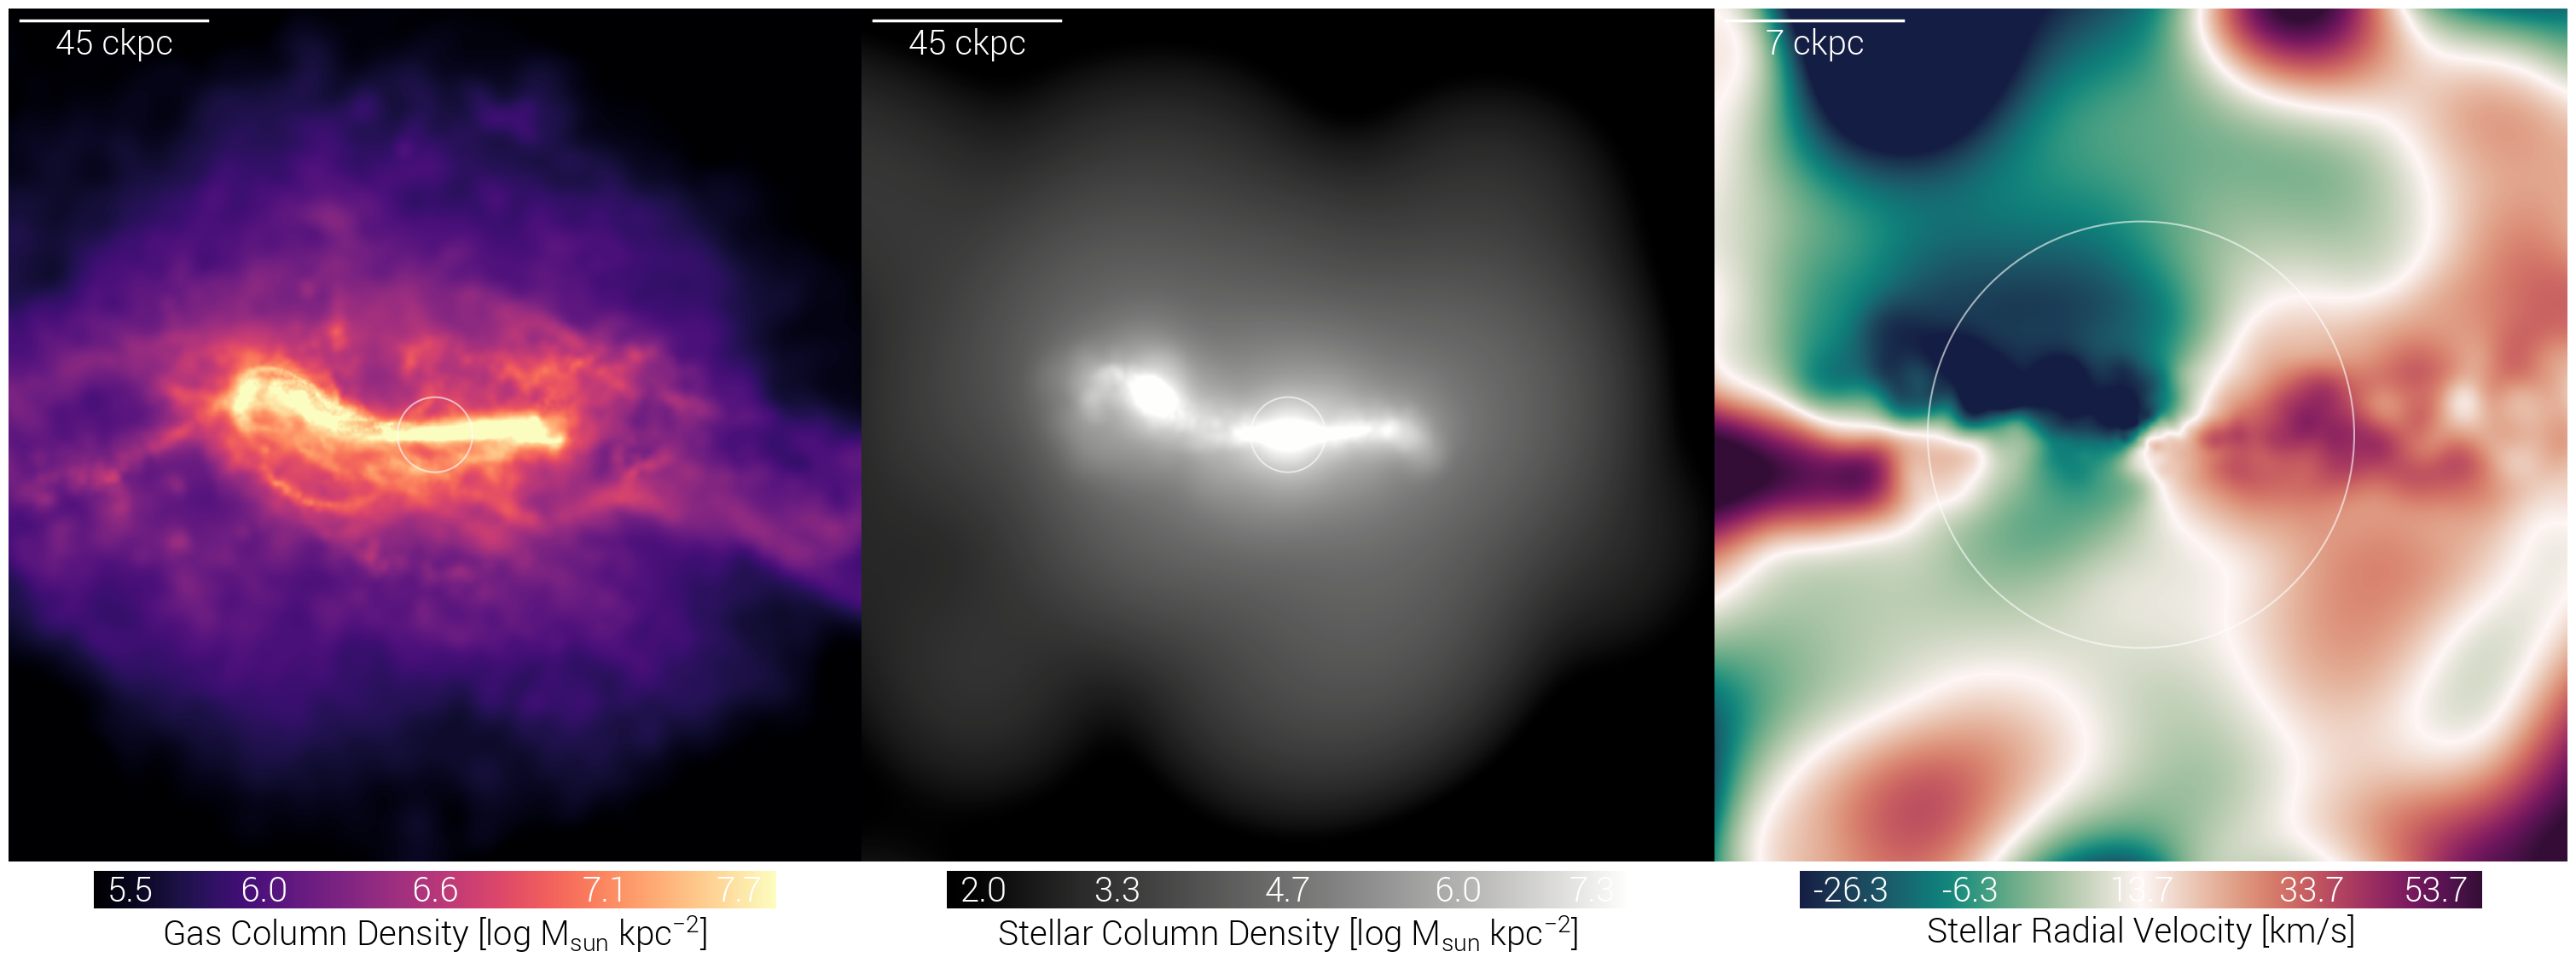


=== subhalo 67504: log M*=10.24, sat_ratio=0.65 ===
Saved [/leonardo/home/userexternal/acosta01/temet.cache/e7f3dd93/cache/f_momentOfInertiaTensor_472e82503357e9c4.hdf5].
Loaded [/leonardo/home/userexternal/acosta01/temet.cache/e7f3dd93/cache/f_momentOfInertiaTensor_472e82503357e9c4.hdf5].
Loaded [/leonardo/home/userexternal/acosta01/temet.cache/e7f3dd93/cache/f_momentOfInertiaTensor_472e82503357e9c4.hdf5].
Saved: [grids//sphMap.67.gas.coldens_msunkpc2.c052386d06d75cf7.hdf5]
 saved: [hsml/hsml.67.stars.63117592-63175199.ngb32.hdf5]
Saved: [grids//sphMap.67.stars.coldens_msunkpc2.8e35b7f0942b9bec.hdf5]
 saved: [hsml/hsml.67.stars.63117592-63175199.hdf5]


/leonardo/home/userexternal/acosta01/software/temet/temet/util/units.py:829: RuntimeWarning: invalid value encountered in divide
  vrad = (gas_vel[:, 0] * xyz[:, 0] + gas_vel[:, 1] * xyz[:, 1] + gas_vel[:, 2] * xyz[:, 2]) / rad


Saved: [grids//sphMap.67.stars.vrad.f25c4e64fdf08e6d.hdf5]


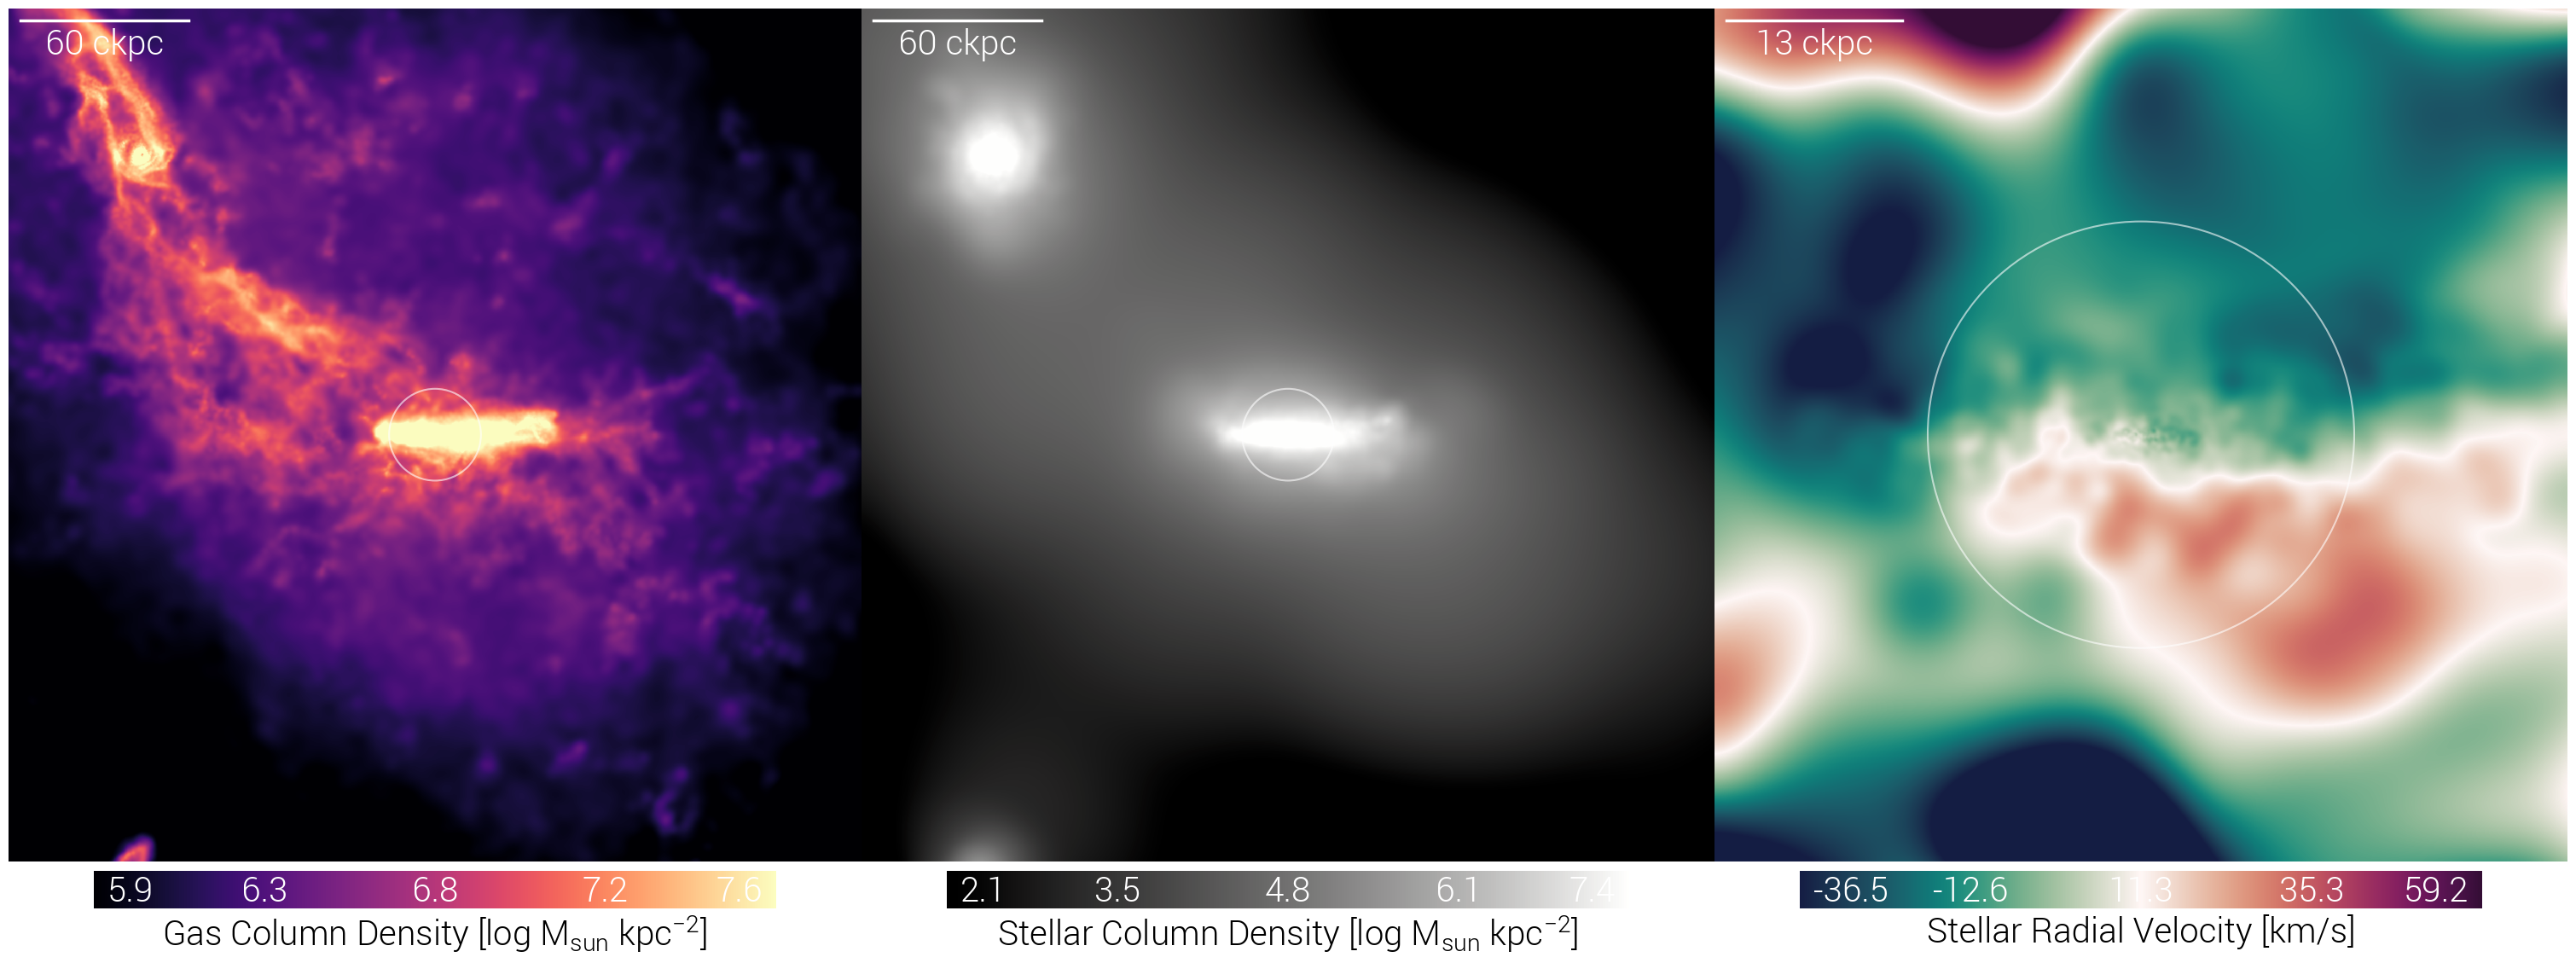


=== subhalo 64312: log M*=10.59, sat_ratio=0.35 ===
Saved [/leonardo/home/userexternal/acosta01/temet.cache/e7f3dd93/cache/f_momentOfInertiaTensor_744466406aabdf44.hdf5].
Loaded [/leonardo/home/userexternal/acosta01/temet.cache/e7f3dd93/cache/f_momentOfInertiaTensor_744466406aabdf44.hdf5].
Loaded [/leonardo/home/userexternal/acosta01/temet.cache/e7f3dd93/cache/f_momentOfInertiaTensor_744466406aabdf44.hdf5].
Saved: [grids//sphMap.67.gas.coldens_msunkpc2.5ad09abf762acddd.hdf5]
 saved: [hsml/hsml.67.stars.59639486-59747876.ngb32.hdf5]
Saved: [grids//sphMap.67.stars.coldens_msunkpc2.a46b237ecb3a17ee.hdf5]
 saved: [hsml/hsml.67.stars.59639486-59747876.hdf5]
Saved: [grids//sphMap.67.stars.vrad.4276b6971d65f71f.hdf5]


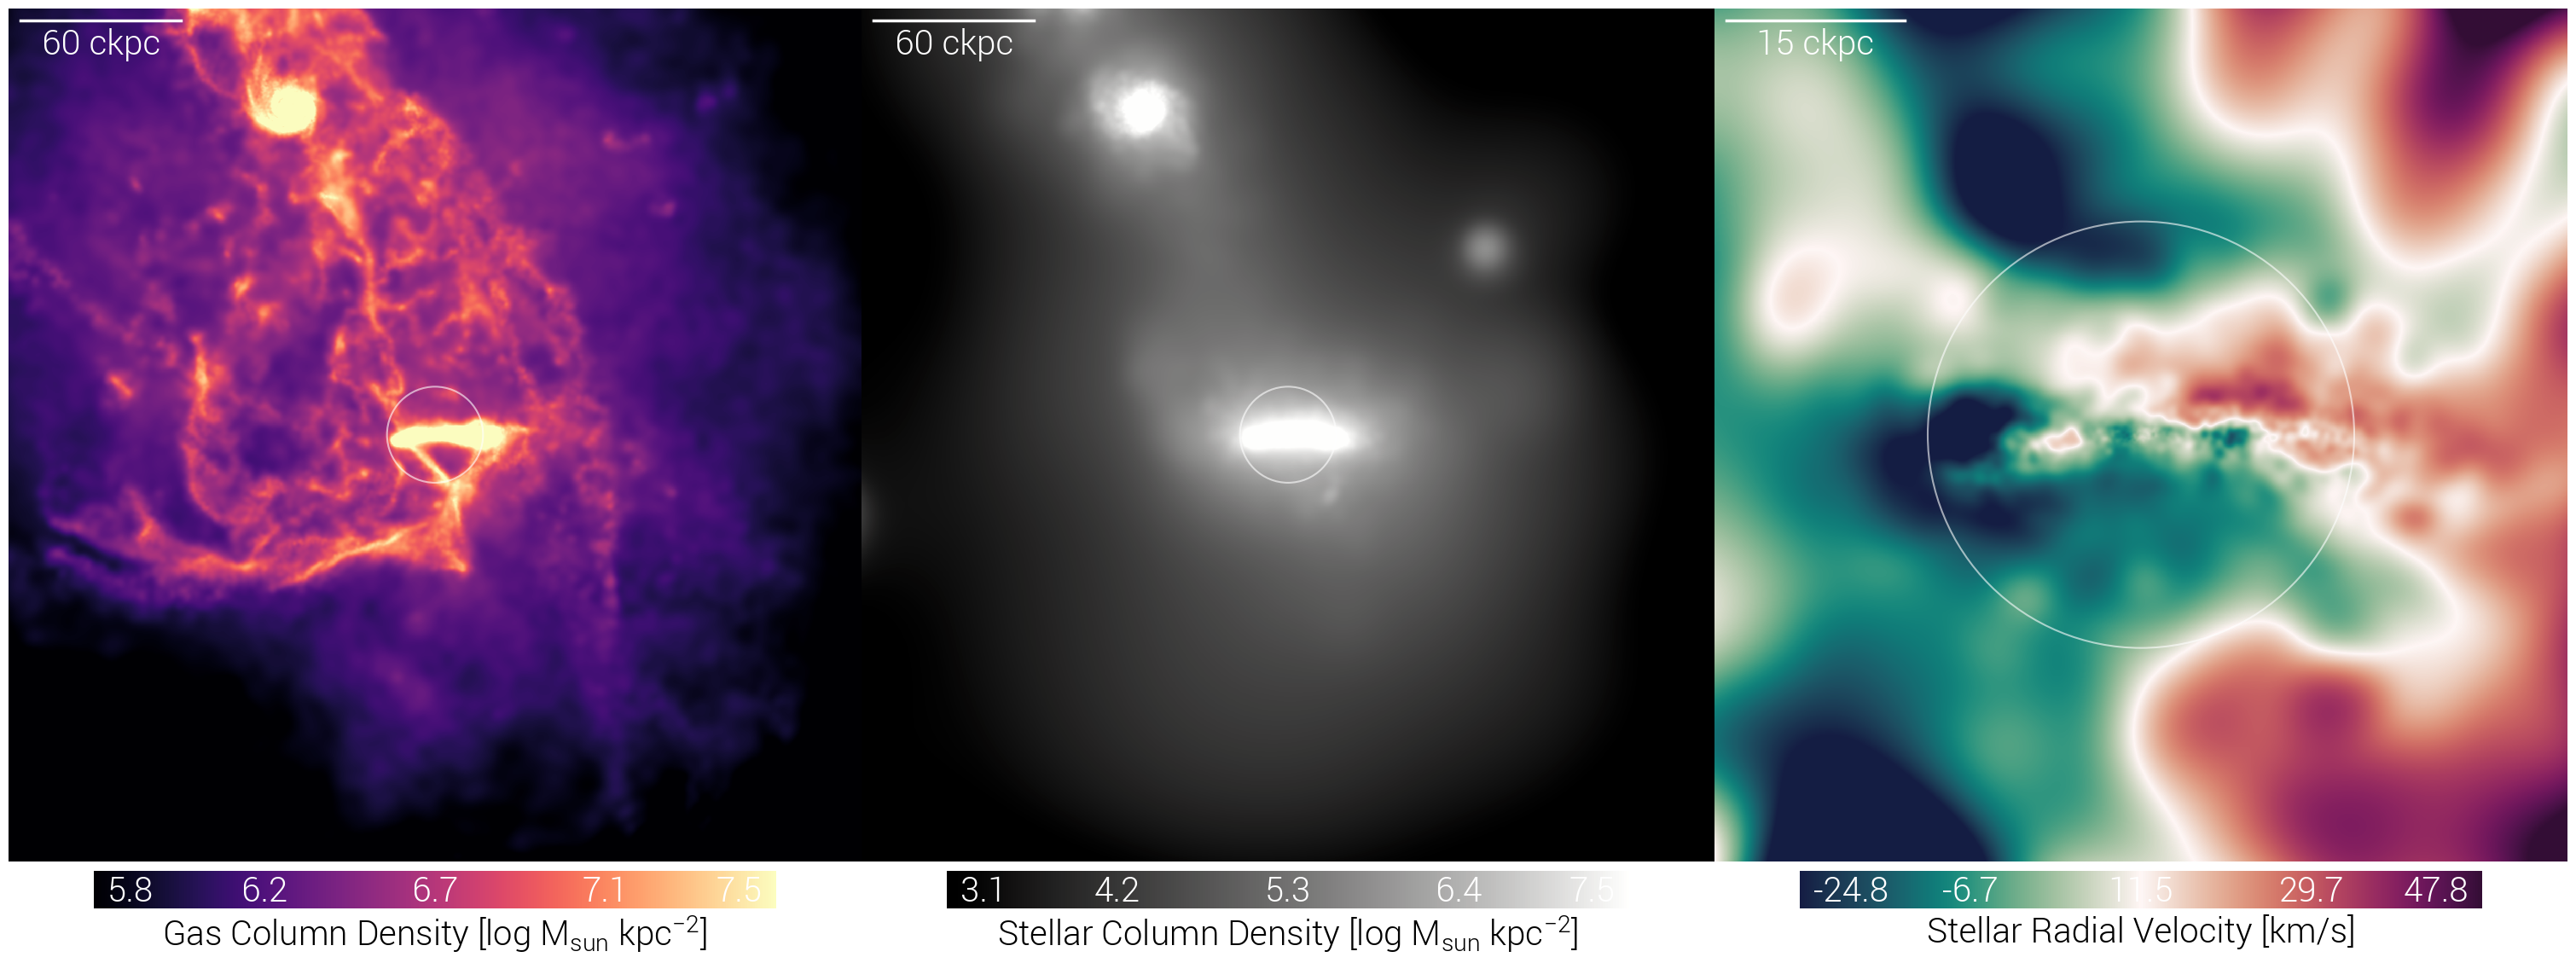


=== subhalo 43846: log M*=11.17, sat_ratio=0.27 ===
Loaded [/leonardo/home/userexternal/acosta01/temet.cache/e7f3dd93/cache/f_momentOfInertiaTensor_d0e63bc2d3bfbafe.hdf5].
Loaded [/leonardo/home/userexternal/acosta01/temet.cache/e7f3dd93/cache/f_momentOfInertiaTensor_d0e63bc2d3bfbafe.hdf5].
Loaded [/leonardo/home/userexternal/acosta01/temet.cache/e7f3dd93/cache/f_momentOfInertiaTensor_d0e63bc2d3bfbafe.hdf5].
Loaded: [grids//sphMap.67.gas.coldens_msunkpc2.426640624d08973a.hdf5]
Loaded: [grids//sphMap.67.stars.coldens_msunkpc2.3e7f91b62159bc0e.hdf5]
Loaded: [grids//sphMap.67.stars.vrad.fa3352cb62980ca3.hdf5]


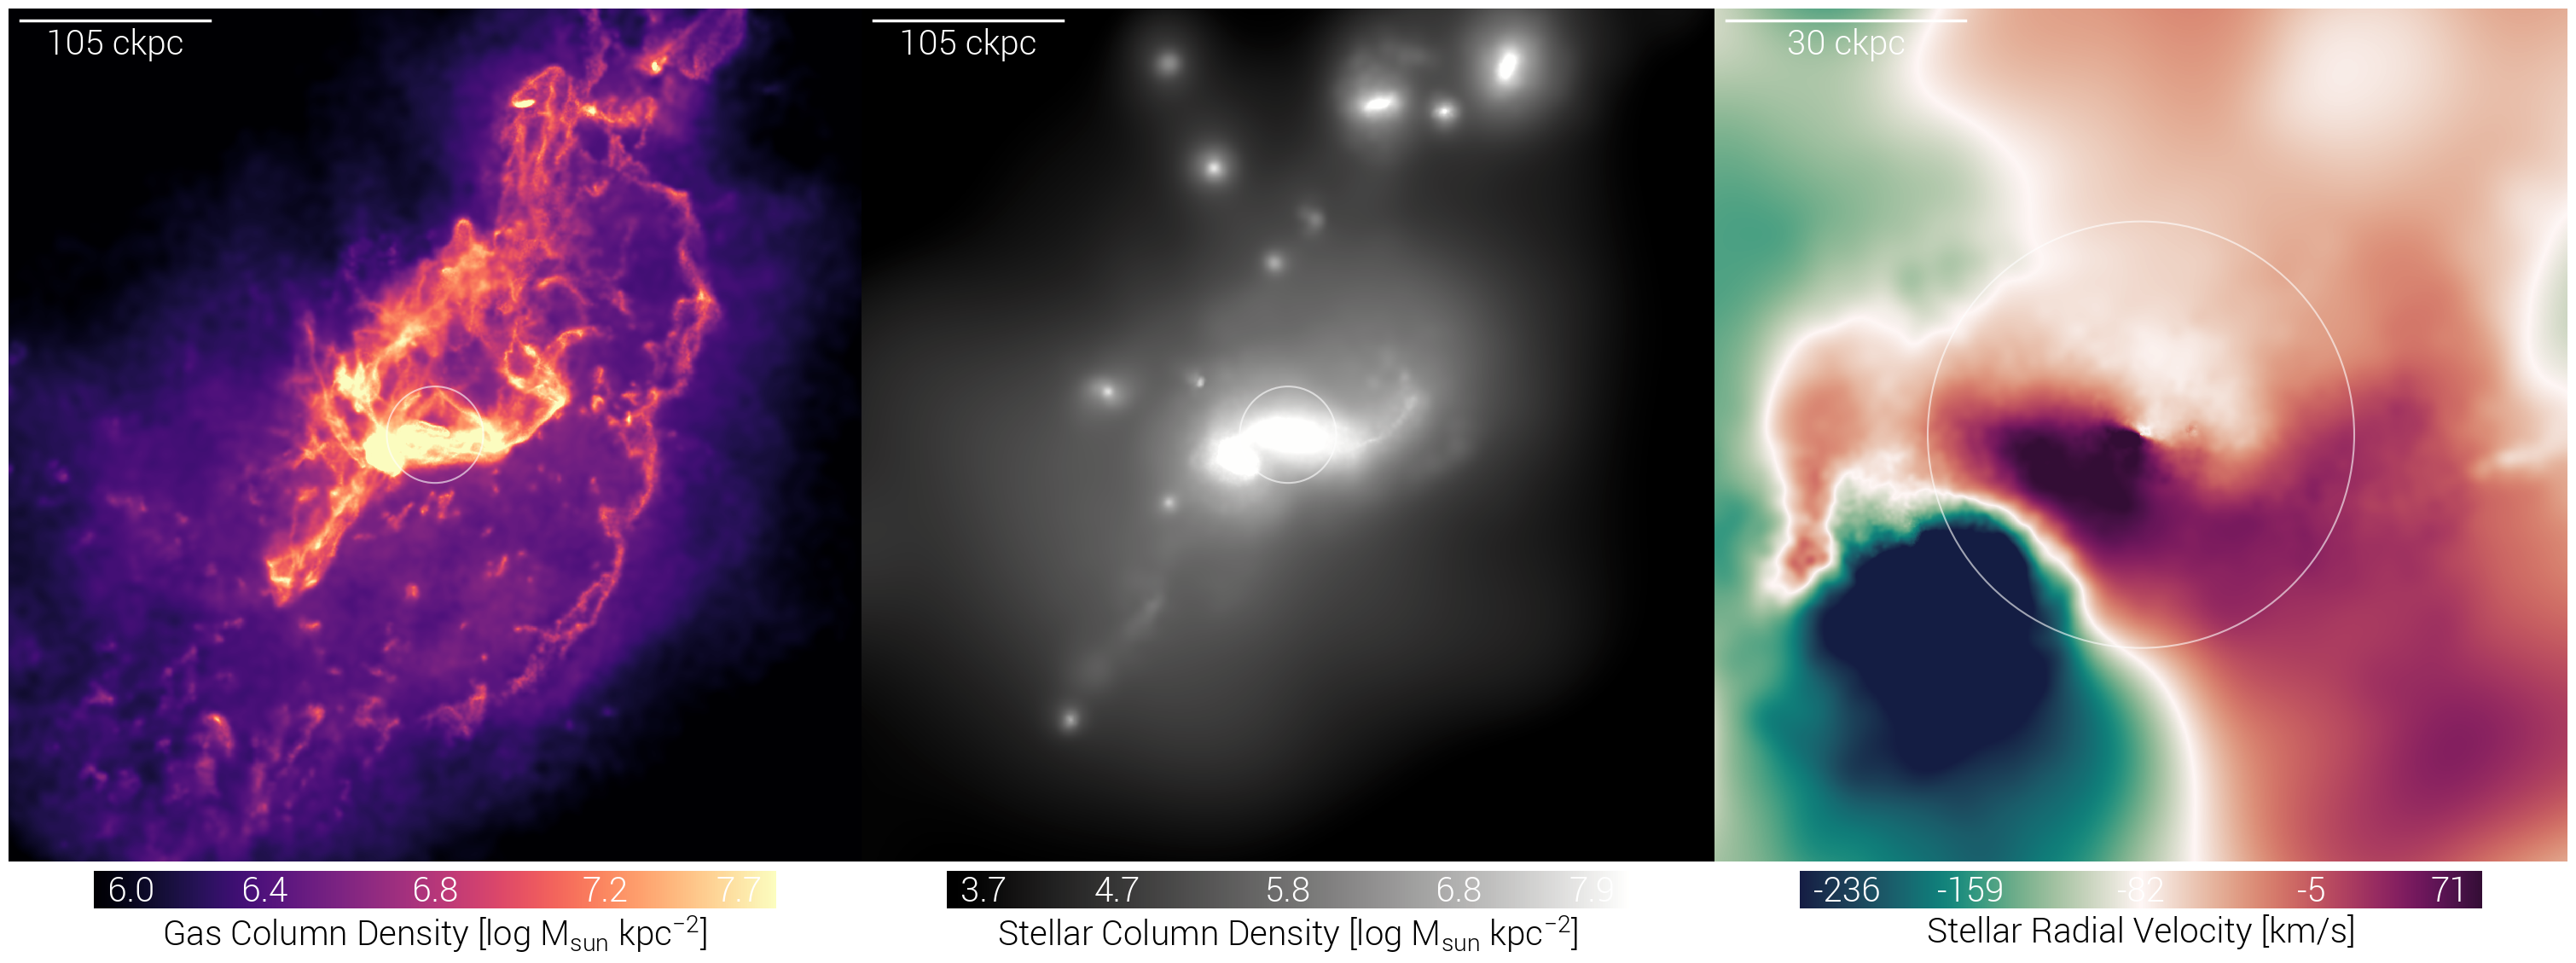


=== subhalo 15985: log M*=11.61, sat_ratio=0.21 ===
Loaded [/leonardo/home/userexternal/acosta01/temet.cache/e7f3dd93/cache/f_momentOfInertiaTensor_d0807eafff75117a.hdf5].
Loaded [/leonardo/home/userexternal/acosta01/temet.cache/e7f3dd93/cache/f_momentOfInertiaTensor_d0807eafff75117a.hdf5].
Loaded [/leonardo/home/userexternal/acosta01/temet.cache/e7f3dd93/cache/f_momentOfInertiaTensor_d0807eafff75117a.hdf5].
Loaded: [grids//sphMap.67.gas.coldens_msunkpc2.3e0d0b3da161f07f.hdf5]
Loaded: [grids//sphMap.67.stars.coldens_msunkpc2.da5249590f3bb974.hdf5]
Loaded: [grids//sphMap.67.stars.vrad.ec66dbca5ce0745b.hdf5]


In [ ]:
# Visualize 6 interacting CDM galaxies (sat_mass_ratio >= 0.2)
df_cdm = mordor_dfs['CDM']
interacting = df_cdm[df_cdm['sat_mass_ratio'] >= 0.2].copy()
interacting = interacting.sort_values('Mstar')
interacting = interacting[interacting.index != 0]

print(f'CDM interacting galaxies (sat M*/M* >= 0.2): {len(interacting)} / {len(df_cdm)} '
      f'({100*len(interacting)/len(df_cdm):.1f}%)')

n_pick = 6
n = len(interacting)
pick_idx = np.linspace(0, n-1, n_pick).astype(int)
picks = interacting.iloc[pick_idx]
print(f'\nSelected {n_pick} galaxies (log M_star -> subhalo_id, sat_ratio):')
for sid, row in picks.iterrows():
    print(f'  log M*={np.log10(row["Mstar"]):.2f}  subhalo {sid}  '
          f'sat_ratio={row["sat_mass_ratio"]:.2f}')

sim_cdm = sims['CDM']
config = {'plotStyle': 'edged', 'saveFilename': None}
for sid, row in picks.iterrows():
    panels = [
        {'partType': 'gas',   'partField': 'coldens_msunkpc2'},
        {'partType': 'stars', 'partField': 'coldens_msunkpc2'},
        {'partType': 'stars', 'partField': 'vrad', 'size': 6.0, 'sizeType': 'rHalfMassStars'},
    ]
    common = dict(
        sP=sim_cdm,
        subhaloInd=int(sid),
        size=1.0,
        rVirFracs=[1.5],
        fracsType='rHalfMassStars',
        sizeType='rVirial',
        rotation='edge-on',
        labelScale=True,
    )
    print(f'\n=== subhalo {sid}: log M*={np.log10(row["Mstar"]):.2f}, '
          f'sat_ratio={row["sat_mass_ratio"]:.2f} ===')
    temet.vis.halo.renderSingleHalo(panels, config, common)


## Disc fraction vs $M_\star$ across redshift

D/T (= fraction of galaxies with `IsDisc==1`) versus $\log M_\star$ at z = 0.5, 1, 2, 3, 4, 5, with three model curves per panel. Wilson 95% CI errorbars.

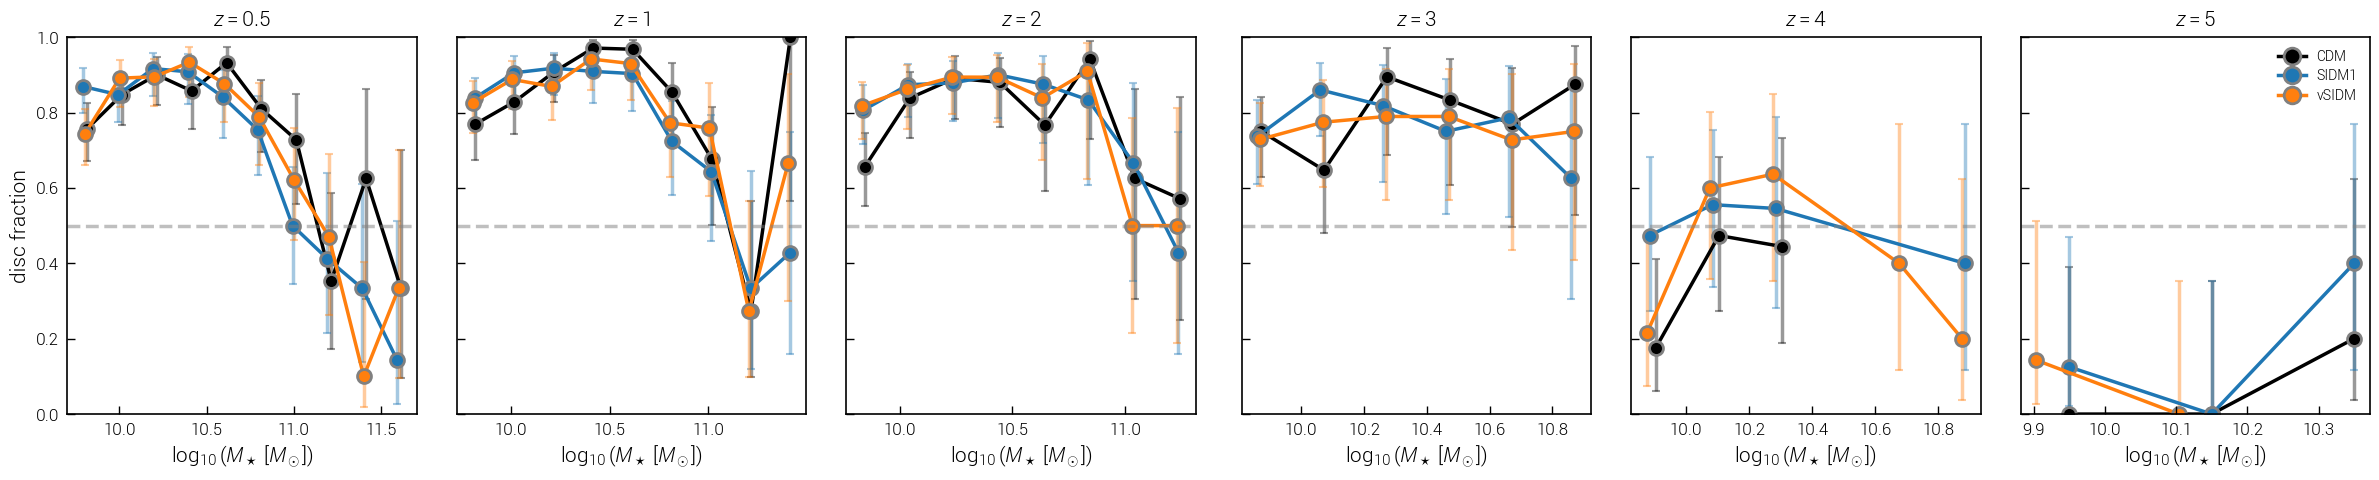

In [12]:
DT_SNAPS_Z = {67: 0.5, 50: 1.0, 33: 2.0, 25: 3.0, 21: 4.0, 17: 5.0}
OUTPUTS_ROOT = OUT_ROOT / 'outputs'

mordor_z = {snap: {} for snap in DT_SNAPS_Z}
for snap in DT_SNAPS_Z:
    for model in MODELS:
        path = OUTPUTS_ROOT / f'snap_{snap:03d}' / f'morphology_{model}.txt'
        if not path.exists() or path.stat().st_size == 0:
            print(f'MISSING: {path}')
            continue
        df = parse_mordor_output(path)
        mordor_z[snap][model] = df

n_cols = len(DT_SNAPS_Z)
fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 5),
                          sharey=True, constrained_layout=True)
for j, (snap, z) in enumerate(DT_SNAPS_Z.items()):
    ax = axes[j]
    for model in MODELS:
        if model not in mordor_z[snap]:
            continue
        df = mordor_z[snap][model]
        log_m = np.log10(df['Mstar'].values)
        bins = np.arange(log_m.min(), log_m.max() + 0.2, 0.2)
        centres, fracs, lo, hi = [], [], [], []
        for i in range(len(bins) - 1):
            m = (log_m >= bins[i]) & (log_m < bins[i + 1])
            n_total = int(m.sum())
            if n_total >= 5:
                n_disc = int((df['IsDisc'].values[m] == 1).sum())
                f = n_disc / n_total
                l, h = binom_conf_interval(n_disc, n_total,
                                            confidence_level=0.95,
                                            interval='wilson')
                centres.append(0.5 * (bins[i] + bins[i + 1]))
                fracs.append(f)
                lo.append(f - l)
                hi.append(h - f)
        if not centres:
            continue
        yerr = np.clip(np.array([lo, hi]), 0, None)
        ax.plot(centres, fracs, '-o', color=model_colors[model], label=model,
                ms=10, markeredgecolor='grey', markeredgewidth=2)
        ax.errorbar(centres, fracs, yerr=yerr, fmt='none',
                    color=model_colors[model], alpha=0.4,
                    capsize=3, capthick=1.5, zorder=0)
    ax.axhline(0.5, color='gray', ls='--', alpha=0.5)
    ax.set_xlabel(r'$\log_{10}(M_\star\;[M_\odot])$')
    ax.set_title(f'$z = {z:g}$')
    ax.set_ylim(0, 1)

axes[0].set_ylabel('disc fraction')
axes[-1].legend(loc='upper right', fontsize=10)
plt.savefig(FIG_DIR / 'dt_vs_mstar_mosaic_redshift.pdf', dpi=150,
             bbox_inches='tight')
plt.show()

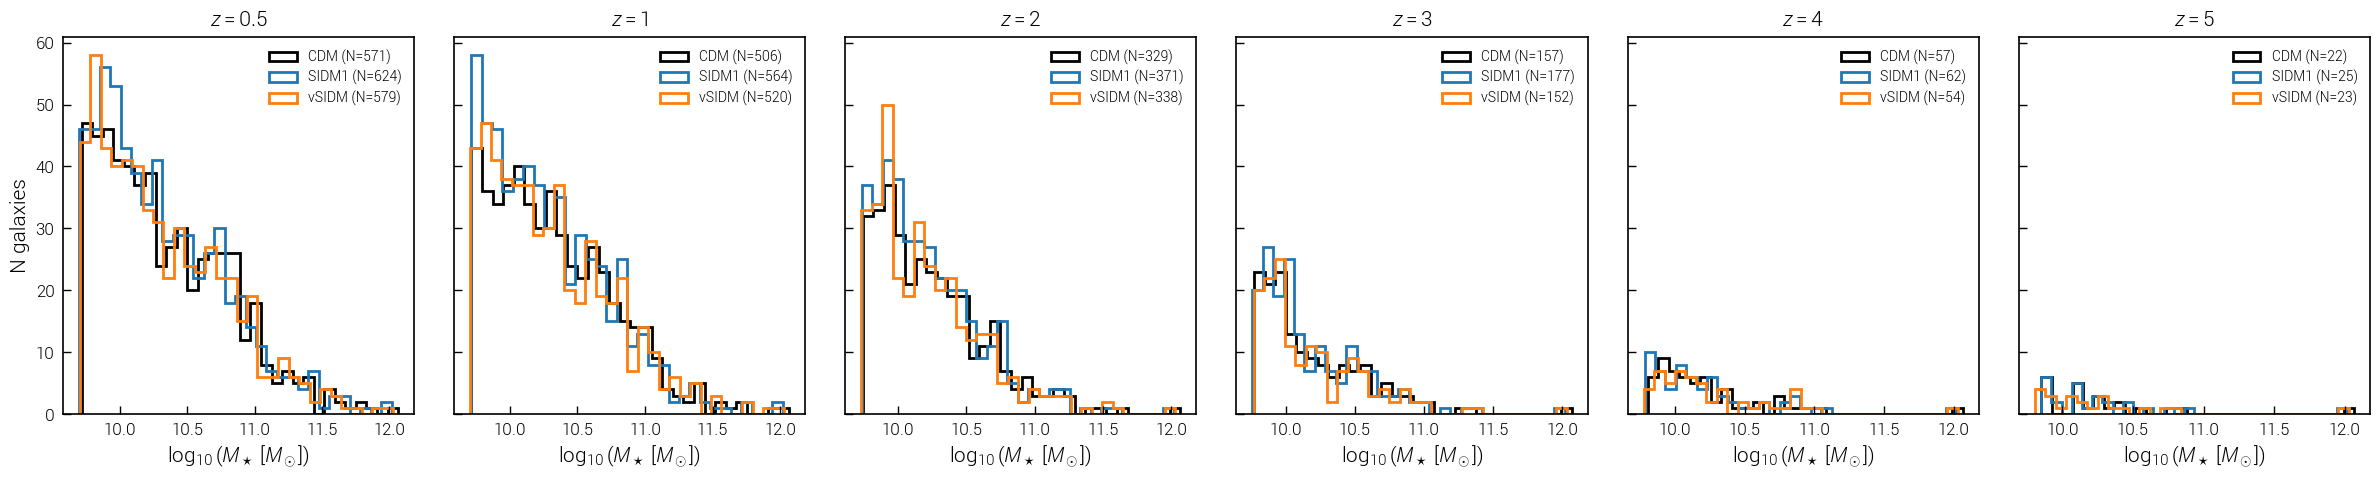

In [13]:
n_cols = len(DT_SNAPS_Z)
fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 5),
                          sharey=True, constrained_layout=True)
for j, (snap, z) in enumerate(DT_SNAPS_Z.items()):
    ax = axes[j]
    for model in MODELS:
        if model not in mordor_z[snap]:
            continue
        df = mordor_z[snap][model]
        ax.hist(np.log10(df['Mstar']), bins=30, histtype='step', lw=2,
                color=model_colors[model],
                label=f'{model} (N={len(df)})')
    ax.set_xlabel(r'$\log_{10}(M_\star\;[M_\odot])$')
    ax.set_title(f'$z = {z:g}$')
    ax.legend(fontsize=10)

axes[0].set_ylabel('N galaxies')
plt.savefig(FIG_DIR / 'sample_histogram_mosaic_redshift.pdf', dpi=150,
             bbox_inches='tight')
plt.show()


z = 0.5  (snap 67)  Mthin/Mstar percentiles (16, 50, 84):
  CDM: median=0.582  [16, 84]=[0.343, 0.722]  (N=571)
  SIDM1: median=0.542  [16, 84]=[0.317, 0.723]  (N=624)
  vSIDM: median=0.540  [16, 84]=[0.306, 0.723]  (N=579)

z = 1.0  (snap 50)  Mthin/Mstar percentiles (16, 50, 84):
  CDM: median=0.572  [16, 84]=[0.347, 0.697]  (N=506)
  SIDM1: median=0.553  [16, 84]=[0.322, 0.692]  (N=564)
  vSIDM: median=0.537  [16, 84]=[0.327, 0.689]  (N=520)

z = 2.0  (snap 33)  Mthin/Mstar percentiles (16, 50, 84):
  CDM: median=0.463  [16, 84]=[0.268, 0.612]  (N=329)
  SIDM1: median=0.481  [16, 84]=[0.287, 0.619]  (N=371)
  vSIDM: median=0.473  [16, 84]=[0.281, 0.620]  (N=338)

z = 3.0  (snap 25)  Mthin/Mstar percentiles (16, 50, 84):
  CDM: median=0.367  [16, 84]=[0.207, 0.508]  (N=157)
  SIDM1: median=0.385  [16, 84]=[0.216, 0.532]  (N=177)
  vSIDM: median=0.341  [16, 84]=[0.208, 0.486]  (N=152)

z = 4.0  (snap 21)  Mthin/Mstar percentiles (16, 50, 84):
  CDM: median=0.229  [16, 84]=[0.079, 0.3

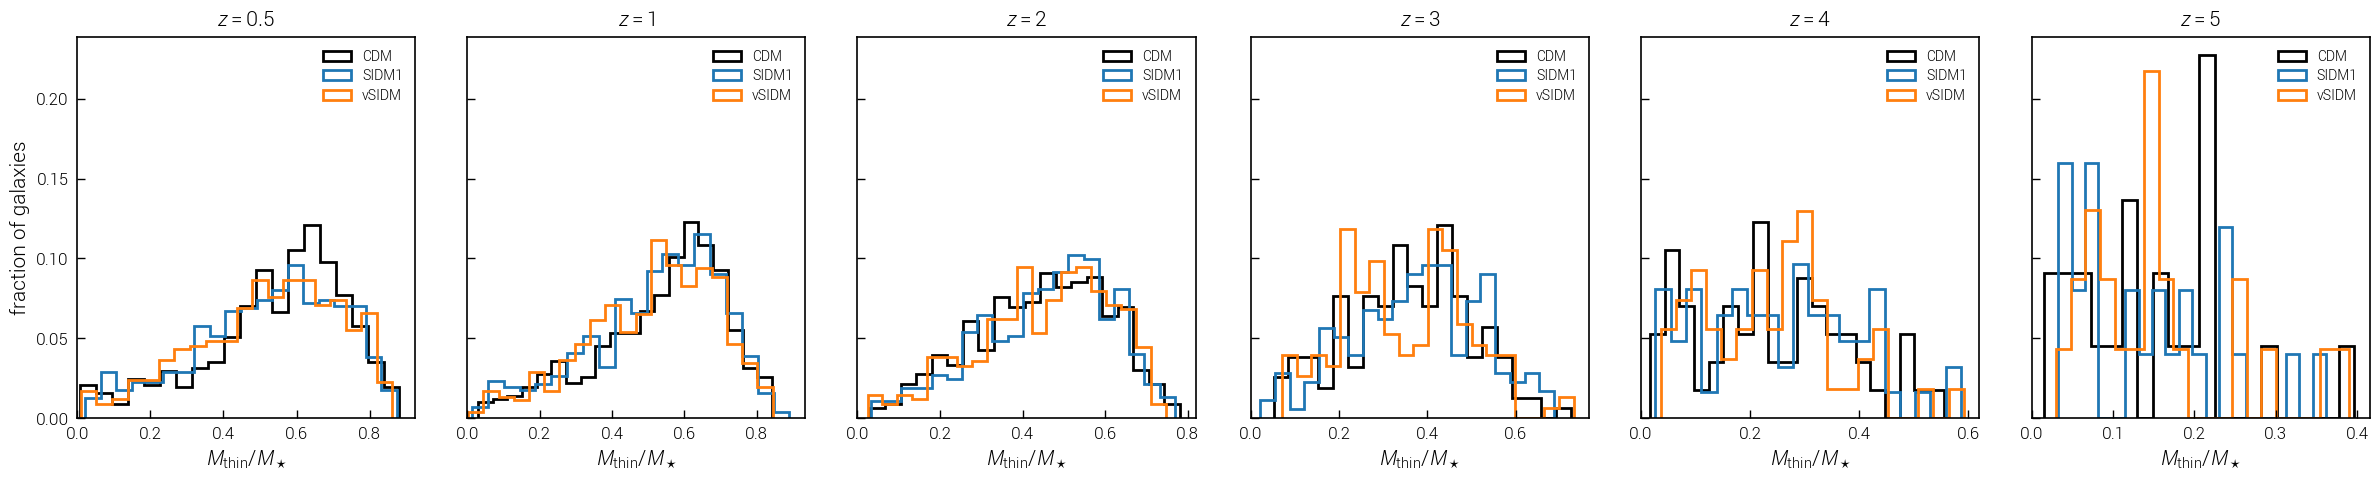

In [14]:
n_cols = len(DT_SNAPS_Z)
fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 5),
                          sharey=True, constrained_layout=True)
for j, (snap, z) in enumerate(DT_SNAPS_Z.items()):
    ax = axes[j]
    print(f'\nz = {z}  (snap {snap})  Mthin/Mstar percentiles (16, 50, 84):')
    for model in MODELS:
        if model not in mordor_z[snap]:
            continue
        df = mordor_z[snap][model]
        x = ((df['Mthin']+df['Mthick']) / df['Mstar']).values
        if len(x) == 0:
            continue
        weights = np.ones_like(x) / len(x)
        ax.hist(x, bins=20, weights=weights, histtype='step', lw=2,
                color=model_colors[model], label=model)
        p16, p50, p84 = np.percentile(x, [16, 50, 84])
        print(f'  {model}: median={p50:.3f}  [16, 84]=[{p16:.3f}, {p84:.3f}]  (N={len(x)})')
    ax.set_xlabel(r'$M_{\rm thin} / M_\star$')
    ax.set_title(f'$z = {z:g}$')
    ax.set_xlim(0)
    ax.legend(fontsize=10)

axes[0].set_ylabel('fraction of galaxies')
plt.savefig(FIG_DIR / 'mthin_over_mstar_mosaic_redshift.pdf', dpi=150,
             bbox_inches='tight')
plt.show()